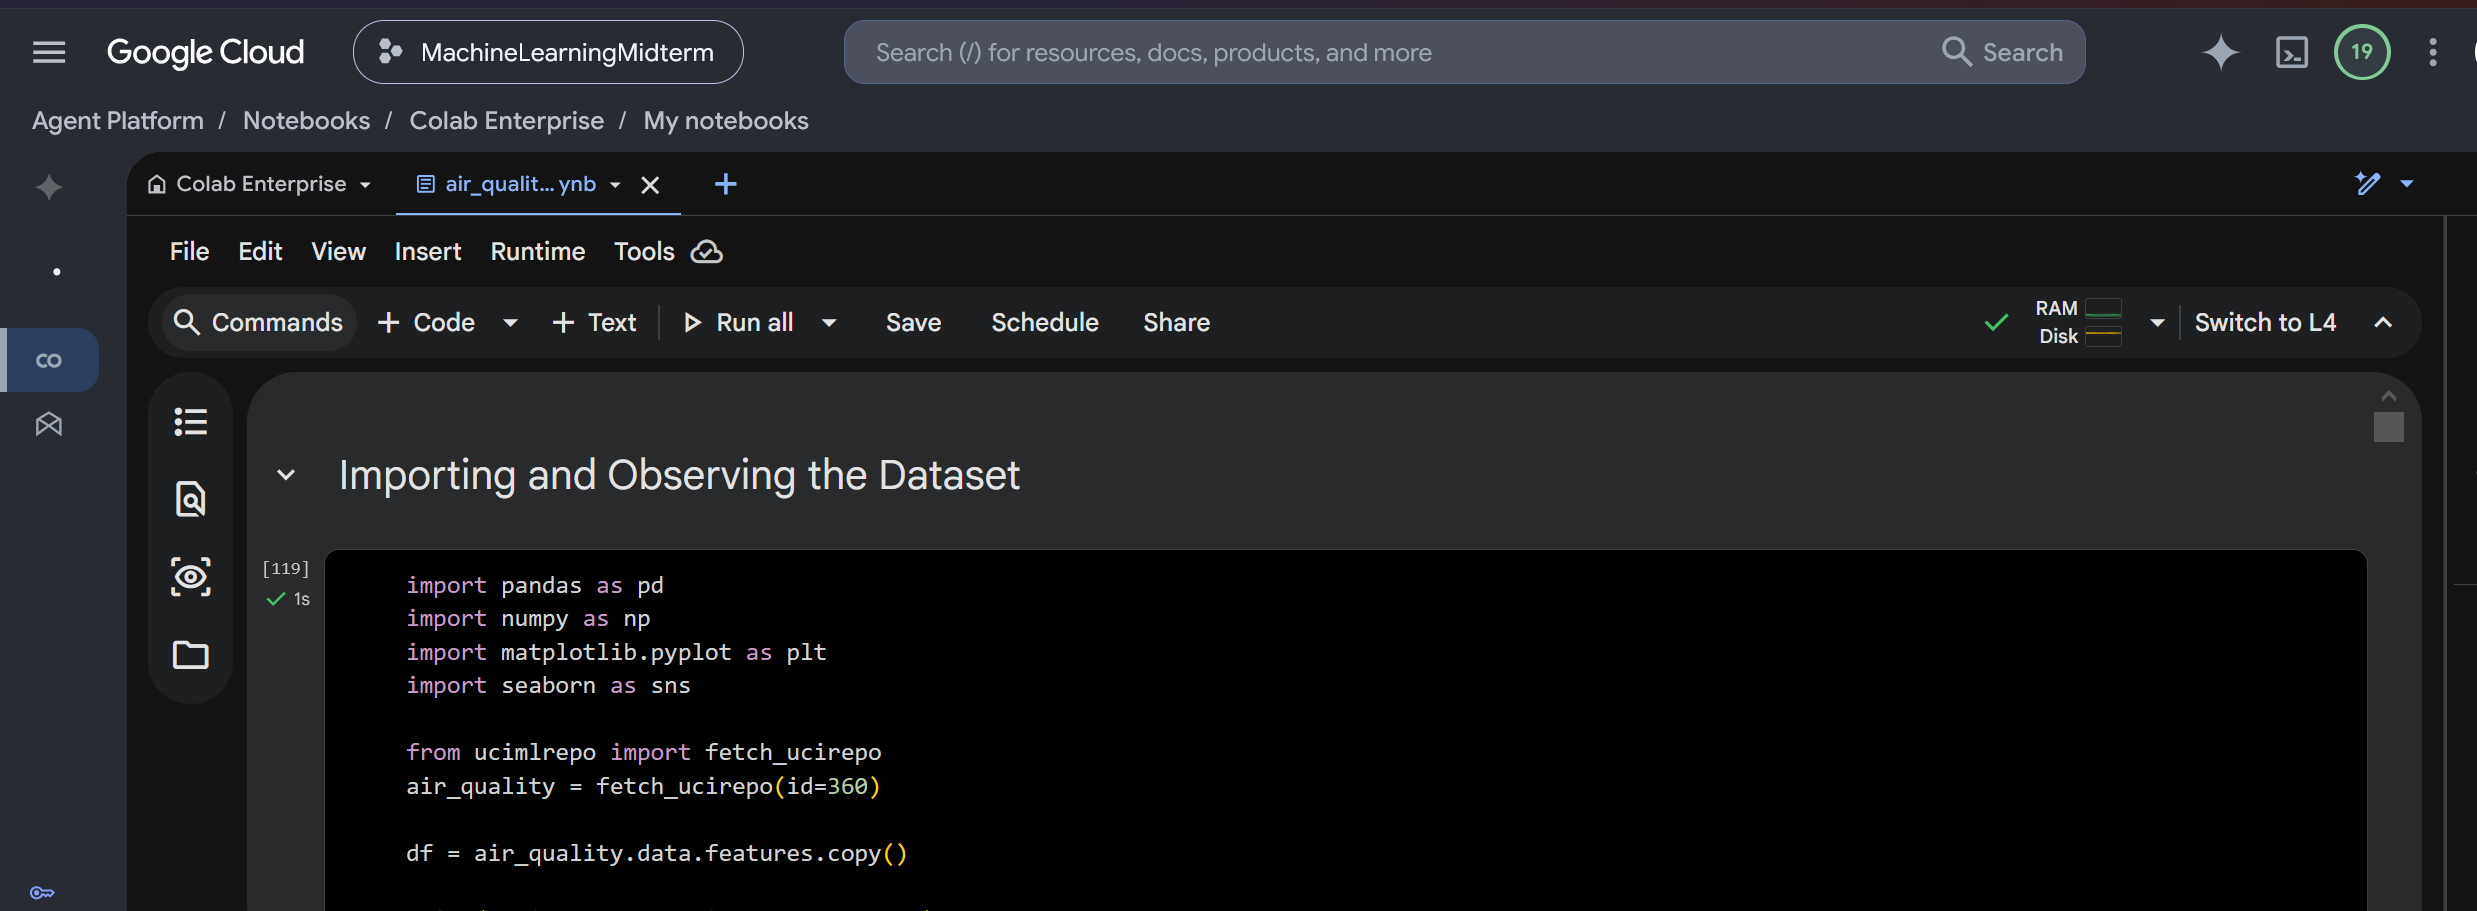

## Importing and Observing the Dataset



In [15]:
!pip install ucimlrepo

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
air_quality = fetch_ucirepo(id=360)

df = air_quality.data.features.copy()

print(f'First 5 Items in the dataset:')
display(df.head())

print('\nColumn Information:')
display(df.info())

First 5 Items in the dataset:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


None

In [17]:
display(df['CO(GT)'].value_counts())
display(df['T'].value_counts())

,count
CO(GT),
-200.0,1683
1.0,305
1.4,279
1.6,275
1.5,273
...,...
10.1,1
9.9,1
9.4,1


,count
T,
-200.0,366
20.8,57
21.3,54
13.8,51
20.2,51
...,...
1.7,1
-1.2,1
-1.9,1


In [18]:
print('Dataset Description:')
display(df.describe().T)

print('\nNull Values:')
display(df.isnull().sum())

Dataset Description:


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000



Null Values:


,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [19]:
print('Null Values:')
display((df == -200).sum())

Null Values:


,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


## Imputing Missing Values

In [20]:
print(f'{(df['NMHC(GT)'] == -200).sum() / len(df) * 100:.2f}% of NMHC(GT) data is missing, so it is dropped.')
df.drop(columns=['NMHC(GT)'], inplace=True)

90.23% of NMHC(GT) data is missing, so it is dropped.


In [21]:
df.replace(-200, np.nan, inplace=True)
pct = (df.isnull().sum() / len(df) * 100).round(1)
pd.DataFrame({"null": df.isnull().sum(), "pct": pct}).sort_values("pct", ascending=False)

,null,pct
CO(GT),1683,18.0
NOx(GT),1639,17.5
NO2(GT),1642,17.5
PT08.S2(NMHC),366,3.9
C6H6(GT),366,3.9
PT08.S1(CO),366,3.9
PT08.S5(O3),366,3.9
T,366,3.9
PT08.S3(NOx),366,3.9
PT08.S4(NO2),366,3.9


In [22]:
from sklearn.impute import SimpleImputer
import numpy as np

numeric_cols = df.select_dtypes("number").columns

imputer = SimpleImputer(strategy='median')
imputedSet = df.copy()

imputedSet[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print(f"New shape: {imputedSet.shape}")
display(imputedSet.describe().T)

New shape: (9357, 14)


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,2.089302,1.323024,0.1000,1.2000,1.8000,2.6000,11.900
PT08.S1(CO),9357.0,1098.392433,212.911465,647.0000,941.0000,1063.0000,1221.0000,2040.000
C6H6(GT),9357.0,10.009447,7.311771,0.1000,4.6000,8.2000,13.6000,63.700
PT08.S2(NMHC),9357.0,937.973923,261.625561,383.0000,743.0000,909.0000,1105.0000,2214.000
NOx(GT),9357.0,235.178903,195.091025,2.0000,112.0000,180.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,834.339959,251.808888,322.0000,666.0000,806.0000,960.0000,2683.000
NO2(GT),9357.0,112.373303,43.948519,2.0000,86.0000,109.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1456.528054,339.370072,551.0000,1242.0000,1463.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,1020.562894,390.784960,221.0000,742.0000,963.0000,1255.0000,2523.000
T,9357.0,18.297574,8.658221,-1.9000,12.0000,17.8000,24.1000,44.600


## Preparing the Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = df.select_dtypes("number").columns
cat_features = df.select_dtypes("object").columns

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Date', 'Time'], dtype='object'))])

## Classifier Models

In [24]:
import time
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score

def run_regression_models(X_train, y_train, X_test, y_test, testVal):
  models = {
      'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
      'SGD Classifier Log Loss': SGDClassifier(loss='log_loss', random_state=42),
      'SGD Classifier Hinge': SGDClassifier(loss='hinge', random_state=42),
      'SGD Classifier Perceptron': SGDClassifier(loss='perceptron', random_state=42),
      'SGD Classifier Log Loss Alpha 0.0001': SGDClassifier(loss='log_loss', alpha=0.0001, random_state=42),
      'SGD Classifier Log Loss Alpha 0.001': SGDClassifier(loss='log_loss', alpha=0.001, random_state=42)
  }

  evaluations = []
  best_model = None
  best_f1 = 0

  for name, model in models.items():
      start_time = time.time()
      pipe = Pipeline(steps=[
          ('preprocessing', ColumnTransformer([
              ('num', clone(num_pipeline), num_features.drop(testVal, errors='ignore')),
              ('cat', clone(cat_pipeline), cat_features)
          ])),
          ('model', model)
      ])

      pipe.fit(X_train, y_train)
      end_time = time.time()

      y_pred = pipe.predict(X_test)

      accuracy = accuracy_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred, average='weighted')

      if f1 > best_f1:
          best_f1 = f1
          best_model = name

      evaluations.append({
          'Model': name,
          'Accuracy': round(accuracy, 2),
          'F1 Score': round(f1, 2),
          'Time': round(end_time - start_time, 2)
      })

  display(pd.DataFrame(evaluations).sort_values(by='F1 Score', ascending=False))
  return best_model

In [25]:
testVal = 'CO(GT)'
df_clean = df.dropna(subset=[testVal])

X = df_clean.drop(columns=[testVal])
y = pd.qcut(df_clean[testVal], q=4, labels=['low', 'medium', 'high', 'very high'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = run_regression_models(X_train, y_train, X_test, y_test, testVal)
print(f"Best model at evaluating {testVal}: {best_model}")

,Model,Accuracy,F1 Score,Time
0,Logistic Regression,0.85,0.85,0.80
1,SGD Classifier Log Loss,0.81,0.80,0.17
2,SGD Classifier Hinge,0.80,0.80,0.11
4,SGD Classifier Log Loss Alpha 0.0001,0.81,0.80,0.13
5,SGD Classifier Log Loss Alpha 0.001,0.77,0.76,0.08
3,SGD Classifier Perceptron,0.73,0.74,0.11


Best model at evaluating CO(GT): Logistic Regression


In [26]:
testVal = 'C6H6(GT)'
df_clean = df.dropna(subset=[testVal])

X = df_clean.drop(columns=[testVal])
y = pd.qcut(df_clean[testVal], q=4, labels=['low', 'medium', 'high', 'very high'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = run_regression_models(X_train, y_train, X_test, y_test, testVal)
print(f"Best model at evaluating {testVal}: {best_model}")

,Model,Accuracy,F1 Score,Time
0,Logistic Regression,0.96,0.96,0.31
1,SGD Classifier Log Loss,0.88,0.88,0.17
4,SGD Classifier Log Loss Alpha 0.0001,0.88,0.88,0.14
2,SGD Classifier Hinge,0.87,0.87,0.14
3,SGD Classifier Perceptron,0.87,0.87,0.11
5,SGD Classifier Log Loss Alpha 0.001,0.83,0.83,0.09


Best model at evaluating C6H6(GT): Logistic Regression


## Regression Testing

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

all_coefs = {}

def run_regression(model, testVal, name):
    df_clean = df.dropna(subset=[testVal])
    X = df_clean.drop(columns=[testVal])
    y = df_clean[testVal]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipe = Pipeline([('preprocessing', ColumnTransformer([
              ('num', clone(num_pipeline), num_features.drop(testVal, errors='ignore')),
              ('cat', clone(cat_pipeline), cat_features)
          ])),
           ("model", model)])

    pipe.fit(X_train, y_train)
    all_coefs[name] = pipe.named_steps['model'].coef_

    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
          'Model': name,
          'RMSE': rmse,
          'R^2': r2
      }

alphas = [ 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

models = {
    "Ridge" : Ridge,
    "Lasso" : Lasso,
}

testValues = ['NO2(GT)', 'NOx(GT)']

evaluations = {val: [] for val in testValues}
linearRegEval = []

for testVal in testValues:
    linearRegEval.append(run_regression(LinearRegression(), testVal, 'Linear Regression'))
    for name, model in models.items():
        for alphaVal in alphas:
            results = run_regression(model(alpha=alphaVal, max_iter=10000), testVal, name + f' (alpha={alphaVal})')
            evaluations[testVal].append(results)

print(f"Linear Regression Evaluation:")
display(pd.DataFrame(linearRegEval).sort_values(by='R^2', ascending=False))

print(f"\nRidge and Lasso Regression Evaluation:")
for testVal, data in evaluations.items():
    print(f"\nEvaluating {testVal}:")
    display(pd.DataFrame(data).sort_values(by='R^2', ascending=False))


Linear Regression Evaluation:


,Model,RMSE,R^2
1,Linear Regression,65.443719,0.898387
0,Linear Regression,15.859122,0.884770



Ridge and Lasso Regression Evaluation:

Evaluating NO2(GT):


,Model,RMSE,R^2
3,Ridge (alpha=0.1),15.846388,0.884955
10,Lasso (alpha=0.0001),15.855620,0.884821
2,Ridge (alpha=0.01),15.855933,0.884816
11,Lasso (alpha=0.001),15.857050,0.884800
1,Ridge (alpha=0.001),15.857662,0.884791
0,Ridge (alpha=0.0001),15.857859,0.884788
4,Ridge (alpha=1),15.943328,0.883543
12,Lasso (alpha=0.01),16.389171,0.876939
5,Ridge (alpha=10),16.947592,0.868410
6,Ridge (alpha=100),20.630151,0.805010



Evaluating NOx(GT):


,Model,RMSE,R^2
4,Ridge (alpha=1),65.250882,0.898985
3,Ridge (alpha=0.1),65.253274,0.898978
1,Ridge (alpha=0.001),65.260511,0.898955
2,Ridge (alpha=0.01),65.260636,0.898955
0,Ridge (alpha=0.0001),65.262722,0.898948
11,Lasso (alpha=0.001),65.430171,0.898429
10,Lasso (alpha=0.0001),65.441728,0.898393
12,Lasso (alpha=0.01),65.658504,0.897719
5,Ridge (alpha=10),66.840883,0.894002
13,Lasso (alpha=0.1),70.729773,0.881309


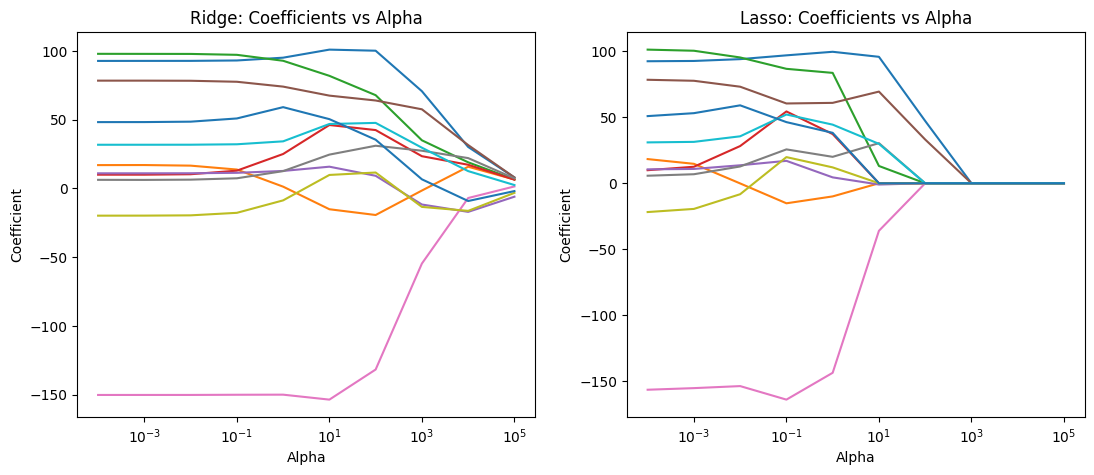

In [28]:
n = len(num_features) - 1  # numeric columns come first in the transformed data

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    coefs = np.array([all_coefs[f"{name} (alpha={a})"] for a in alphas])
    ax.semilogx(alphas, coefs[:, :n])
    ax.set_title(f"{name}: Coefficients vs Alpha")
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Coefficient")
plt.show()

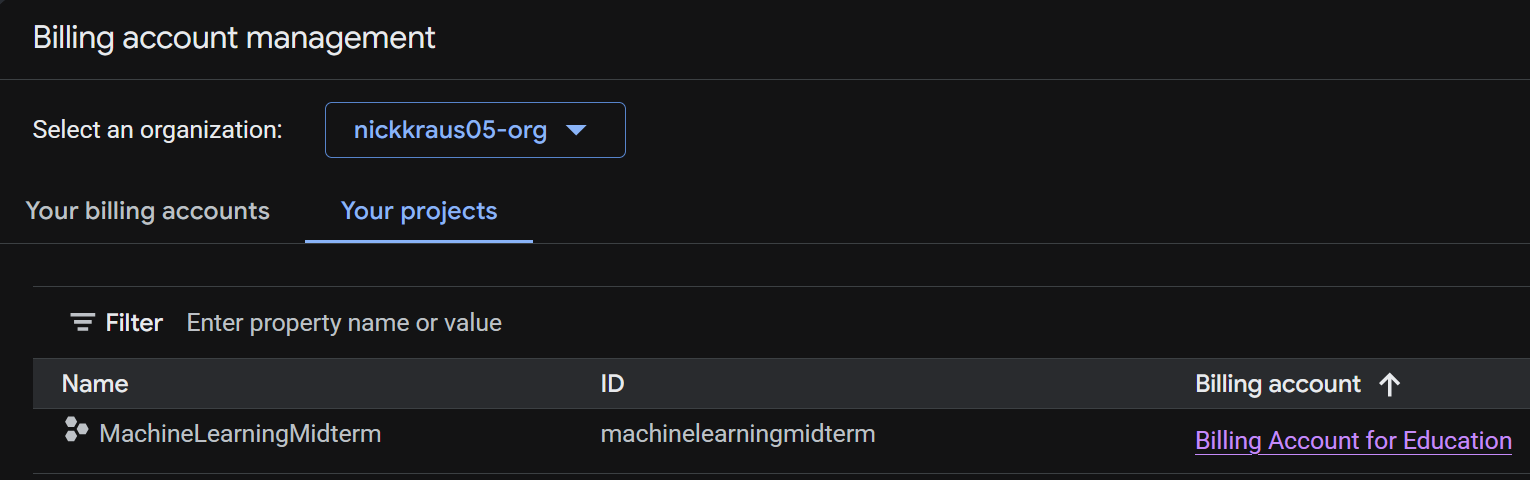

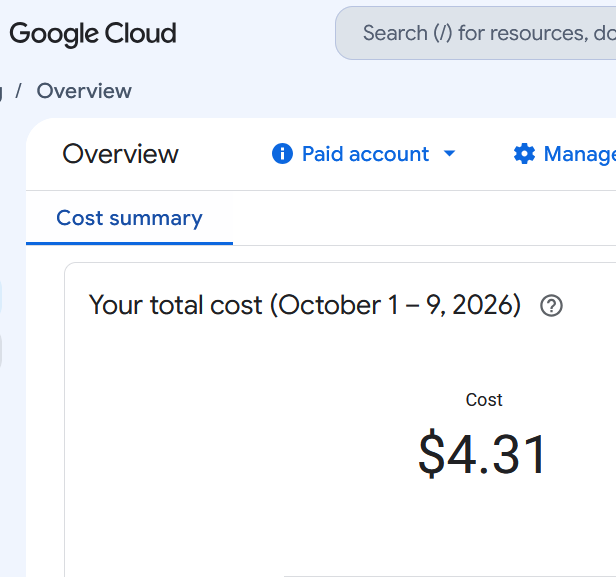